# Tourism Heat Exposure under NASA CMIP6 Climate Projections

**A scoping analysis of projected extreme heat exposure for major global tourism destinations.**

Author: Hanem Ellethy, PhD · Brisbane, QLD · 2026

---

This notebook supports an application for the Research Fellow position on the ARC Discovery Project *Extreme Heat in Cities: Co-Developing Just Adaptation for Urban Tourism* (DP260101699), Griffith Institute for Tourism.

It prototypes an end-to-end pipeline that:
1. Connects to NASA's NEX-GDDP-CMIP6 daily downscaled climate projections
2. Samples them at 10 major tourism cities
3. Computes a simple heat-exposure metric (days/year with Tmax > 35 °C)
4. Visualises change across IPCC time horizons and emissions scenarios

The notebook addresses two distinct questions in sequence:

- **Question A — Trajectory:** When does the heat arrive under continued high emissions?
- **Question B — Emissions sensitivity:** How much of the heat burden is avoidable through mitigation?

In [22]:
# Install / import everything we need
import ee
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# Authenticate Earth Engine, first run will open a popup; sign in with the same Google account
ee.Authenticate()
ee.Initialize(project='pacific-attic-433804-u4')

sns.set_style("whitegrid")
print("✅ Earth Engine ready.")

✅ Earth Engine ready.


## 1. City sampling frame

Ten cities sampled to span five world regions (Europe, Asia Pacific, North America, Middle East, Australasia) and four climate zones (temperate, tropical, subtropical, arid).

Each city sits in the top tier of major tourism indices including Euromonitor's *Top 100 City Destinations* and Mastercard's *Global Destination Cities*.

A full ARC-scale study would extend to the formally ranked Top 100.

In [23]:
cities = pd.DataFrame([
    ("Paris",     "Europe",         48.8566,   2.3522),
    ("Tokyo",     "Asia Pacific",   35.6762, 139.6503),
    ("New York",  "North America",  40.7128, -74.0060),
    ("Singapore", "Asia Pacific",    1.3521, 103.8198),
    ("Bangkok",   "Asia Pacific",   13.7563, 100.5018),
    ("Dubai",     "Middle East",    25.2048,  55.2708),
    ("Sydney",    "Australasia",   -33.8688, 151.2093),
    ("Rome",      "Europe",         41.9028,  12.4964),
    ("London",    "Europe",         51.5074,  -0.1278),
    ("Hong Kong", "Asia Pacific",   22.3193, 114.1694),
], columns=["city", "region", "lat", "lon"])

cities


,city,region,lat,lon
0,Paris,Europe,48.8566,2.3522
1,Tokyo,Asia Pacific,35.6762,139.6503
2,New York,North America,40.7128,-74.0060
3,Singapore,Asia Pacific,1.3521,103.8198
4,Bangkok,Asia Pacific,13.7563,100.5018
5,Dubai,Middle East,25.2048,55.2708
6,Sydney,Australasia,-33.8688,151.2093
7,Rome,Europe,41.9028,12.4964
8,London,Europe,51.5074,-0.1278
9,Hong Kong,Asia Pacific,22.3193,114.1694


## 2. Core function — query NASA NEX-GDDP-CMIP6

The function below queries Earth Engine for one city × one scenario × one time window, and returns the average number of days per year above the 35 °C threshold.

A single climate model (**ACCESS-CM2**) is used for this scoping analysis. A full study would report multi-model ensemble medians with 10–90 percentile ranges.

In [24]:
def get_heat_days(lat, lon, scenario, year_start, year_end, model="ACCESS-CM2"):
    """
    Return mean annual count of days where daily Tmax > 35 °C (308.15 K)
    at a given location, for one CMIP6 scenario and time window.
    """
    point = ee.Geometry.Point([lon, lat])
    coll = (ee.ImageCollection("NASA/GDDP-CMIP6")
            .filter(ee.Filter.eq("model", model))
            .filter(ee.Filter.eq("scenario", scenario))
            .filter(ee.Filter.calendarRange(year_start, year_end, "year"))
            .select("tasmax"))

    hot_days = coll.map(lambda img: img.gt(308.15))
    total = hot_days.sum().reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=point,
        scale=27830,
    ).get("tasmax")

    n_years = year_end - year_start + 1
    return ee.Number(total).divide(n_years).getInfo()


# Sanity check — Bangkok baseline should land roughly 60–100 days/year
test = get_heat_days(13.7563, 100.5018, "historical", 1995, 2014)
print(f"✅ Bangkok 1995–2014 baseline: {test:.1f} heat days/year")

✅ Bangkok 1995–2014 baseline: 88.9 heat days/year


## 3. Run the full extraction

We query five horizons per city, four for Question A (trajectory under SSP5-8.5), plus one additional horizon for Question B (the SSP2-4.5 end-century comparison).

| Label | Scenario | Years | Used in |
|---|---|---|---|
| `hist_1995_2014` | historical | 1995–2014 | A + B |
| `near_2021_2040` | SSP5-8.5 | 2021–2040 | A |
| `mid_2041_2060` | SSP5-8.5 | 2041–2060 | A |
| `end_2081_2100` | SSP5-8.5 | 2081–2100 | A + B |
| `end_2081_2100_ssp245` | SSP2-4.5 | 2081–2100 | B |

10 cities × 5 horizons = 50 NASA queries, ~12 minutes total.

In [25]:
results = []

horizons = [
    ("hist_1995_2014", "historical", 1995, 2014),
    ("near_2021_2040", "ssp585",     2021, 2040),
    ("mid_2041_2060",  "ssp585",     2041, 2060),
    ("end_2081_2100",  "ssp585",     2081, 2100),]

pbar = tqdm(total=len(cities) * len(horizons), desc="Querying NASA NEX-GDDP-CMIP6")
for _, city in cities.iterrows():
    for label, scenario, ys, ye in horizons:
        try:
            days = get_heat_days(city["lat"], city["lon"], scenario, ys, ye)
        except Exception as e:
            print(f"  ⚠️ {city['city']} / {label}: {e}")
            days = None
        results.append({
            "city": city["city"],
            "region": city["region"],
            "horizon": label,
            "heat_days_per_year": days,
        })
        pbar.update(1)
pbar.close()

df = pd.DataFrame(results)
df.to_csv("results.csv", index=False)
print(f"\n✅ Done. {len(df)} rows saved to results.csv")
df.head()


Querying NASA NEX-GDDP-CMIP6:   0%|          | 0/40 [00:00<?, ?it/s]


✅ Done. 40 rows saved to results.csv


,city,region,horizon,heat_days_per_year
0,Paris,Europe,hist_1995_2014,0.80
1,Paris,Europe,near_2021_2040,1.90
2,Paris,Europe,mid_2041_2060,5.45
3,Paris,Europe,end_2081_2100,32.90
4,Tokyo,Asia Pacific,hist_1995_2014,0.50


# Question A:  When does the heat arrive?

For each city, we plot heat-day exposure across four time periods (1995–2014 baseline through 2081–2100) under the high-emissions SSP5-8.5 pathway.

This trajectory tells us *when* the climate signal crosses thresholds at each destination, and which destinations are already meaningfully exposed today.

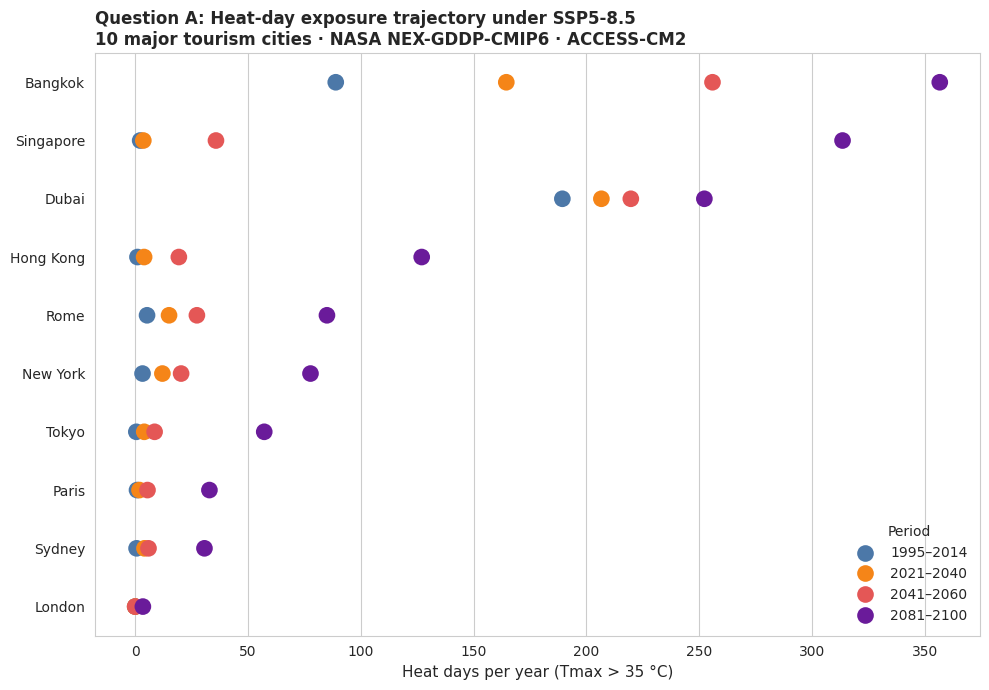

In [38]:
# Filter to Question A horizons
a_horizons = ["hist_1995_2014", "near_2021_2040", "mid_2041_2060", "end_2081_2100"]
a_df = df[df["horizon"].isin(a_horizons)].copy()

a_labels = {
    "hist_1995_2014": "1995–2014",
    "near_2021_2040": "2021–2040",
    "mid_2041_2060":  "2041–2060",
    "end_2081_2100":  "2081–2100",
}
a_df["period"] = a_df["horizon"].map(a_labels)

# Sort cities by end-century value
city_order = (a_df[a_df["horizon"] == "end_2081_2100"]
              .sort_values("heat_days_per_year", ascending=False)["city"].tolist())

palette_a = {
    "1995–2014": "#4C78A8",
    "2021–2040": "#F58518",
    "2041–2060": "#E45756",
    "2081–2100": "#6A1B9A",
}

fig, ax = plt.subplots(figsize=(10, 7))
sns.stripplot(data=a_df, y="city", x="heat_days_per_year",
              hue="period", order=city_order,
              hue_order=list(palette_a.keys()),
              palette=palette_a, size=12, ax=ax, jitter=False)

ax.set_xlabel("Heat days per year (Tmax > 35 °C)", fontsize=11)
ax.set_ylabel("")
ax.set_title("Question A: Heat-day exposure trajectory under SSP5-8.5\n"
             "10 major tourism cities · NASA NEX-GDDP-CMIP6 · ACCESS-CM2",
             fontsize=12, loc="left", weight="bold")
ax.legend(title="Period", loc="lower right", frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig("question_a_trajectory.png", dpi=160, bbox_inches="tight")
plt.show()

### Reading Question A

The trajectory reveals three city archetypes:

- **Already-saturated destinations** (Dubai, Bangkok): high baseline exposure, continuing to grow but approaching the 365-day physical ceiling.
- **Tipping-point destinations** (Singapore, Hong Kong): modest current exposure but a sharp end-century jump.
- **Resilient destinations** (London, Sydney, Paris): limited change across periods.

Each archetype implies a different adaptation pathway, a framing that directly motivates the "just adaptation" question at the heart of the host ARC project.

# Question B: Does mitigation matter?

The trajectory above shows what happens under continued high emissions. But how much of that burden is avoidable?

This section compares end-century (2081–2100) exposure under two contrasting scenarios:

- **SSP2-4.5** : moderate emissions, broadly consistent with current Paris-Agreement-adjacent policy
- **SSP5-8.5** : high emissions, continued fossil-fuelled development

The difference between the two is the **emissions premium**: heat-day burden that effective climate policy could plausibly avert for each destination.

### Adding the SSP2-4.5 comparison horizon

Question A requires only the SSP5-8.5 trajectory (run above). Question B adds one further query, SSP2-4.5 end-century, to enable the scenario comparison.

In [39]:
missing_horizon = "end_2081_2100_ssp245"

if missing_horizon not in df["horizon"].unique():
    print(f"Querying missing horizon: {missing_horizon}\n")
    extra_rows = []
    pbar = tqdm(total=len(cities), desc="SSP2-4.5 end-century")
    for _, city in cities.iterrows():
        try:
            days = get_heat_days(city["lat"], city["lon"], "ssp245", 2081, 2100)
        except Exception as e:
            print(f"  ⚠️ {city['city']}: {e}")
            days = None
        extra_rows.append({
            "city": city["city"],
            "region": city["region"],
            "horizon": missing_horizon,
            "heat_days_per_year": days,
        })
        pbar.update(1)
    pbar.close()

    df = pd.concat([df, pd.DataFrame(extra_rows)], ignore_index=True)
    df.to_csv("results.csv", index=False)
    print(f"\n✅ Added {len(extra_rows)} rows. Total now: {len(df)}")
else:
    print(f"✅ '{missing_horizon}' already present — no action needed.")

# Show the new rows
df[df["horizon"] == missing_horizon]

✅ 'end_2081_2100_ssp245' already present — no action needed.


,city,region,horizon,heat_days_per_year
40,Paris,Europe,end_2081_2100_ssp245,11.80
41,Tokyo,Asia Pacific,end_2081_2100_ssp245,10.80
42,New York,North America,end_2081_2100_ssp245,25.00
43,Singapore,Asia Pacific,end_2081_2100_ssp245,72.95
44,Bangkok,Asia Pacific,end_2081_2100_ssp245,295.30
45,Dubai,Middle East,end_2081_2100_ssp245,223.20
46,Sydney,Australasia,end_2081_2100_ssp245,10.95
47,Rome,Europe,end_2081_2100_ssp245,41.70
48,London,Europe,end_2081_2100_ssp245,0.20
49,Hong Kong,Asia Pacific,end_2081_2100_ssp245,26.25


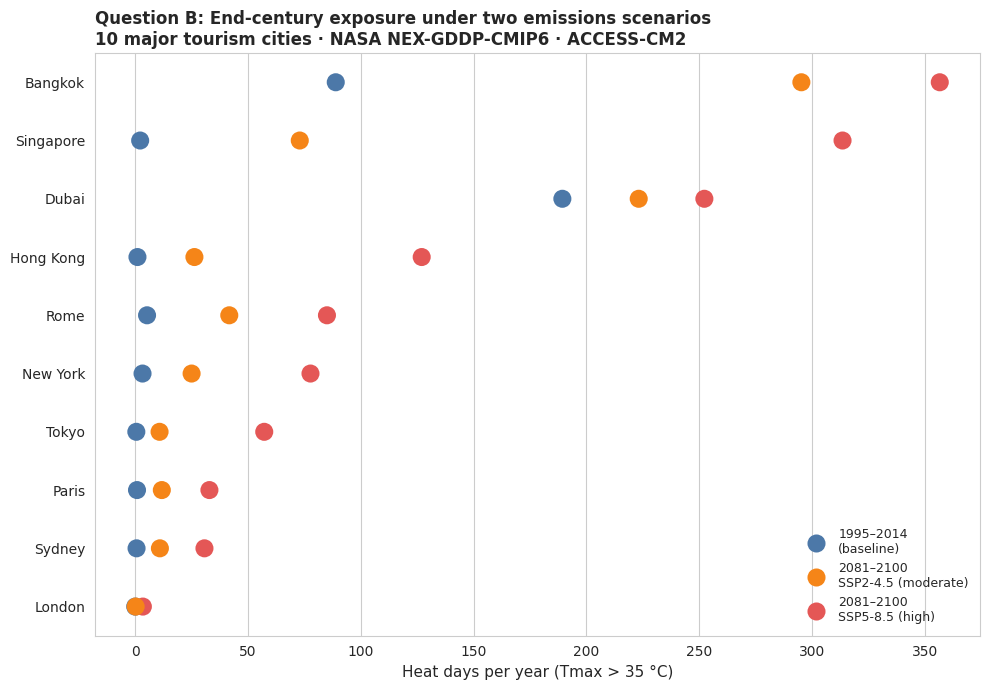

In [40]:
# Filter to Question B horizons
b_horizons = ["hist_1995_2014", "end_2081_2100_ssp245", "end_2081_2100"]
b_df = df[df["horizon"].isin(b_horizons)].copy()
b_df.head()
b_labels = {
    "hist_1995_2014":         "1995–2014\n(baseline)",
    "end_2081_2100_ssp245":   "2081–2100\nSSP2-4.5 (moderate)",
    "end_2081_2100":          "2081–2100\nSSP5-8.5 (high)",
}
b_df["scenario"] = b_df["horizon"].map(b_labels)

palette_b = {
    "1995–2014\n(baseline)":             "#4C78A8",
    "2081–2100\nSSP2-4.5 (moderate)":    "#F58518",
    "2081–2100\nSSP5-8.5 (high)":        "#E45756",
}

fig, ax = plt.subplots(figsize=(10, 7))
sns.stripplot(data=b_df, y="city", x="heat_days_per_year",
              hue="scenario", order=city_order,
              hue_order=list(palette_b.keys()),
              palette=palette_b, size=13, ax=ax, jitter=False)

ax.set_xlabel("Heat days per year (Tmax > 35 °C)", fontsize=11)
ax.set_ylabel("")
ax.set_title("Question B: End-century exposure under two emissions scenarios\n"
             "10 major tourism cities · NASA NEX-GDDP-CMIP6 · ACCESS-CM2",
             fontsize=12, loc="left", weight="bold")
ax.legend(title="", loc="lower right", frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig("question_b_scenarios.png", dpi=160, bbox_inches="tight")
plt.show()

In [41]:
# Compute the "emissions premium",  heat days avoided by limiting emissions
wide = df.pivot(index=["city", "region"], columns="horizon", values="heat_days_per_year").reset_index()
wide["avoided_by_moderate"] = wide["end_2081_2100"] - wide["end_2081_2100_ssp245"]
wide = wide.sort_values("avoided_by_moderate", ascending=False)

summary = wide[["city", "region",
                "hist_1995_2014",
                "end_2081_2100_ssp245",
                "end_2081_2100",
                "avoided_by_moderate"]].round(1)
summary.columns = ["City", "Region", "Baseline", "SSP2-4.5 (2090)",
                   "SSP5-8.5 (2090)", "Heat days AVOIDED by moderate policy"]
summary

,City,Region,Baseline,SSP2-4.5 (2090),SSP5-8.5 (2090),Heat days AVOIDED by moderate policy
7,Singapore,Asia Pacific,2.2,73.0,313.6,240.6
2,Hong Kong,Asia Pacific,1.0,26.2,127.0,100.8
0,Bangkok,Asia Pacific,88.9,295.3,356.6,61.3
4,New York,North America,3.2,25.0,77.7,52.7
9,Tokyo,Asia Pacific,0.5,10.8,57.2,46.4
6,Rome,Europe,5.2,41.7,85.0,43.3
1,Dubai,Middle East,189.4,223.2,252.3,29.1
5,Paris,Europe,0.8,11.8,32.9,21.1
8,Sydney,Australasia,0.6,11.0,30.7,19.8
3,London,Europe,0.0,0.2,3.4,3.2


### A subtle but important pattern

The emissions premium is not simply a function of how hot a city becomes, it is a function of *where the city sits relative to saturation*.

- **Singapore** (premium: +241 days) sits below the threshold under moderate emissions but is pushed firmly above it under high emissions. Mitigation matters enormously.
- **Bangkok** (premium: +61) is already at 295 days/year under moderate emissions. Even successful mitigation leaves it functionally in heat extremes most of the year.
- **Dubai** (premium: +29) is approaching the 365-day physical ceiling under any scenario.

**Policy implication.** For cities like Singapore and Hong Kong, global mitigation is the most impactful intervention. For cities like Bangkok and Dubai, mitigation alone is insufficient, adaptation becomes essential regardless of emissions pathway. This bifurcation of city archetypes, *mitigation-responsive* versus *adaptation-mandatory* — is a substantive finding for the host project's framing of equitable urban heat response.

### Reading Question B

The *emissions premium*, the gap between SSP5-8.5 and SSP2-4.5 dots, quantifies what mitigation could deliver for each destination.

- **Tropical Asia Pacific destinations** (Singapore, Bangkok, Hong Kong) have the largest avoidable burdens, often exceeding 100 heat days per year.
- **Temperate destinations** (London, Paris) show smaller absolute differences but comparable proportional reductions.

The pattern reinforces the equity question at the heart of *just adaptation*: who benefits most from mitigation, and who bears substantial residual exposure regardless of policy choice?

# Limitations and proposed extensions

This is a deliberately scoping analysis. A full ARC-scale study would extend it with:

1. **Multi-model ensemble** (5–30 CMIP6 models) with median and 10–90 percentile bounds, rather than the single-model result reported here. ACCESS-CM2 runs slightly warm over tropical regions, so the absolute magnitudes are likely on the high end of plausible projections.
2. **Intra-city resolution** via Landsat-8 / ECOSTRESS land surface temperature for urban heat island layers — the 0.25° grid cannot resolve UHI signals of 2–8 °C within a city.
3. **Humidity-aware indices** (Wet Bulb Globe Temperature) rather than dry-bulb threshold counts; humidity-driven heat stress is a separate, equally important pathway.
4. **Bias correction** against Bureau of Meteorology and equivalent local-station records.
5. **Visitor-flow weighting** so exposure integrates over arrival seasonality rather than uniform annual averages.
6. **Public-health utilisation linkage** mapping projected exposure onto expected visitor health-service demand.

Each extension is methodologically straightforward; this scoping analysis demonstrates the underlying pipeline.

---

**Data and code license:** Underlying NEX-GDDP-CMIP6 is CC0 (NASA). This notebook is MIT-licensed.

**Reference:** Thrasher, B. *et al.* (2022). NASA Global Daily Downscaled Projections, CMIP6. *Scientific Data* 9, 262. https://doi.org/10.1038/s41597-022-01393-4

In [42]:
import os
for f in ["results.csv", "question_a_trajectory.png", "question_b_scenarios.png"]:
    print(f"{f}: {'✅ exists' if os.path.exists(f) else '❌ missing'}")

results.csv: ✅ exists
question_a_trajectory.png: ✅ exists
question_b_scenarios.png: ✅ exists


In [46]:
import json

# Path depends on where your notebook is — try both:
nb_path = "/content/drive/MyDrive/Colab Notebooks/tourism_heat_eda.ipynb"

with open(nb_path, "r") as f:
    nb = json.load(f)

if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]
    with open(nb_path, "w") as f:
        json.dump(nb, f, indent=1)
    print("✅ Widget metadata removed. Re-save to GitHub now.")
else:
    print("ℹ️ No widget metadata found in metadata.widgets.")

✅ Widget metadata removed. Re-save to GitHub now.


In [47]:
import nbformat

# Load the notebook
filename ="/content/drive/MyDrive/Colab Notebooks/tourism_heat_eda.ipynb"
with open(filename, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

# Remove the widgets metadata if it exists
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']
    print("Metadata 'widgets' removed successfully.")

# Save the cleaned notebook
with open(filename, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)

Metadata 'widgets' removed successfully.
